In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-MiniLM-L6-v2")
print(model.max_seq_length)


from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-MiniLM-L6-v2")
print(tokenizer.model_max_length)

text = "word " * 500
tokens = tokenizer.encode(text, truncation=True)
print(len(tokens))

/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


128
512
502


In [4]:
text = "word " * 1000  # very long text
emb = model.encode(text, output_value="token_embeddings")

print("Embedding shape:",emb.shape)

Embedding shape: torch.Size([128, 384])


In [1]:
import pandas as pd
df = pd.read_csv("data/macrotopics_pred.csv")
display(df.head())
len(df)

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,insult,identity_attack,perspective_insult,perspective_severe_toxicity,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",0.000659,0.000117,...,0.000178,0.000138,0.206683,0.021936,0.138744,0.360951,0.367026,0.038566,Others,0.000000
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,...,0.003023,0.006275,0.021224,0.005379,0.008414,0.123468,0.049762,0.029415,Religion,0.000000
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,...,0.000204,0.000156,0.132458,0.010376,0.003292,0.229804,0.062040,0.033386,Others,0.021935
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'id': 449843, 'folder': 'channel_1571505334'...",0.002710,0.000104,...,0.000239,0.000192,0.019419,0.005112,0.001093,0.075294,0.017666,0.022509,Religion,0.005000
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'id': 104116, 'folder': 'channel_1438734111'...",0.001515,0.000100,...,0.000203,0.000143,0.027841,0.004921,0.002368,0.111507,0.019375,0.028207,Environment,0.000000


673587

In [2]:
interest = [
    'War',
    'American Politics',
    'Foreign Policy',
    'Crime, Security and Justice',
    'Health',
    'Religion',
    'Hobbies'
]

macro_colors = {
    "American Politics":             "#6AF5FF",
    "Foreign Policy":              "#76FF7F",
    "Crime, Security and Justice":     "#FF66CC",
    "Health":                  "#522222",
    "Hobbies":       "#DA0000",
    "Religion":                       "#962EAA",
    "War":                         "#5C5C61"
}

df = df[df["macrotopic_pred"].isin(interest)]
len(df)

297101

In [3]:
df.columns

Index(['video_id', 'text', 'channel_title', 'published_at', 'view_count',
       'like_count', 'comment_count', 'occurrences', 'toxicity',
       'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack',
       'perspective_insult', 'perspective_severe_toxicity',
       'perspective_obscene', 'perspective_toxicity',
       'perspective_identity_attack', 'perspective_threat', 'macrotopic_pred',
       'macrotopic_prob'],
      dtype='object')

In [3]:
contagem = df['macrotopic_pred'].value_counts()
display(contagem)

macrotopic_pred
Religion                       111071
American Politics               52998
War                             52846
Foreign Policy                  40410
Hobbies                         18913
Health                          11522
Crime, Security and Justice      9341
Name: count, dtype: int64

In [4]:
cols_metricas = [
    'perspective_toxicity', 
    'perspective_severe_toxicity', 
    'perspective_insult', 
    'perspective_obscene',       
    'perspective_threat', 
    'perspective_identity_attack'
]

df_tabela = df.groupby('macrotopic_pred')[cols_metricas].mean()
df_tabela.index = df_tabela.index.str.replace('perspective_', '').str.replace('_', ' ').str.capitalize()
df_tabela = df_tabela.round(5)

display(df_tabela)

,perspective_toxicity,perspective_severe_toxicity,perspective_insult,perspective_obscene,perspective_threat,perspective_identity_attack
macrotopic_pred,,,,,,
American politics,0.06823,0.05365,0.06258,0.05735,0.05557,0.05862
"Crime, security and justice",0.09987,0.08179,0.08968,0.08812,0.08356,0.09166
Foreign policy,0.05219,0.04344,0.04706,0.04573,0.04465,0.04876
Health,0.04227,0.03149,0.03559,0.03342,0.03231,0.03476
Hobbies,0.04587,0.03682,0.04251,0.04146,0.03715,0.03782
Religion,0.05535,0.04635,0.04894,0.04861,0.04595,0.05093
War,0.09813,0.08414,0.08473,0.08565,0.08784,0.09705


In [5]:
import pandas as pd
import ast
import numpy as np 

num_nulls = 0

def safe_literal_eval(value):
    global num_nulls
    if pd.isna(value):
        num_nulls += 1
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, TypeError, AttributeError):
        return []

df['occurrences'] = df['occurrences'].apply(safe_literal_eval)
print("Número de valores NaN em 'occurrences':", num_nulls)

Número de valores NaN em 'occurrences': 5


In [6]:
def calculate_lifetime(occurrence_list):
    dates = [item.get('date') for item in occurrence_list if item.get('date')]
    
    if not dates:
        return None 
    
    datetime_dates = pd.to_datetime(dates)
    min_date = datetime_dates.min()
    max_date = datetime_dates.max()

    if min_date == max_date:
        return 1
    
    diff_days = (max_date - min_date).days + 1 
    return diff_days


df['lifetime'] = df['occurrences'].apply(calculate_lifetime)
display(df[['occurrences', 'lifetime']].head())

,occurrences,lifetime
1,"[{'id': 60799, 'folder': 'channel_1466271872',...",1.0
3,"[{'id': 449843, 'folder': 'channel_1571505334'...",2.0
6,"[{'id': 28786, 'folder': 'channel_2165208912',...",1.0
7,"[{'id': 33565, 'folder': 'channel_1937328148',...",1.0
8,"[{'id': 15758, 'folder': 'channel_1916977343',...",13.0


In [7]:
df_lifetime_media = df.groupby('macrotopic_pred')['lifetime'].mean().reset_index()

df_lifetime_media = df_lifetime_media.sort_values(
    'lifetime', 
    ascending=False
)

df_lifetime_media = df_lifetime_media.rename(columns={'lifetime': 'mean_lifetime'})
display(df_lifetime_media)

,macrotopic_pred,mean_lifetime
3,Health,20.244836
5,Religion,18.225499
1,"Crime, Security and Justice",10.997431
4,Hobbies,9.822609
6,War,8.613644
0,American Politics,7.558201
2,Foreign Policy,5.839491


In [8]:
import pandas as pd
import ast 

def contar_envios(valor):
    try:
        if isinstance(valor, list):
            return len(valor)
        
        if isinstance(valor, str):
            lista_real = ast.literal_eval(valor)
            return len(lista_real)
            
        return None 
    except:
        return None

df['quantidade_envios'] = df['occurrences'].apply(contar_envios)

analise_envios = df.groupby('macrotopic_pred')['quantidade_envios'].mean().reset_index()

analise_envios = analise_envios.sort_values('quantidade_envios', ascending=False)
analise_envios = analise_envios.set_index('macrotopic_pred')
display(analise_envios.style )

,quantidade_envios
macrotopic_pred,
Health,4.655789
American Politics,3.518529
Religion,3.022625
"Crime, Security and Justice",2.688149
Foreign Policy,2.390918
War,2.193846
Hobbies,1.993497


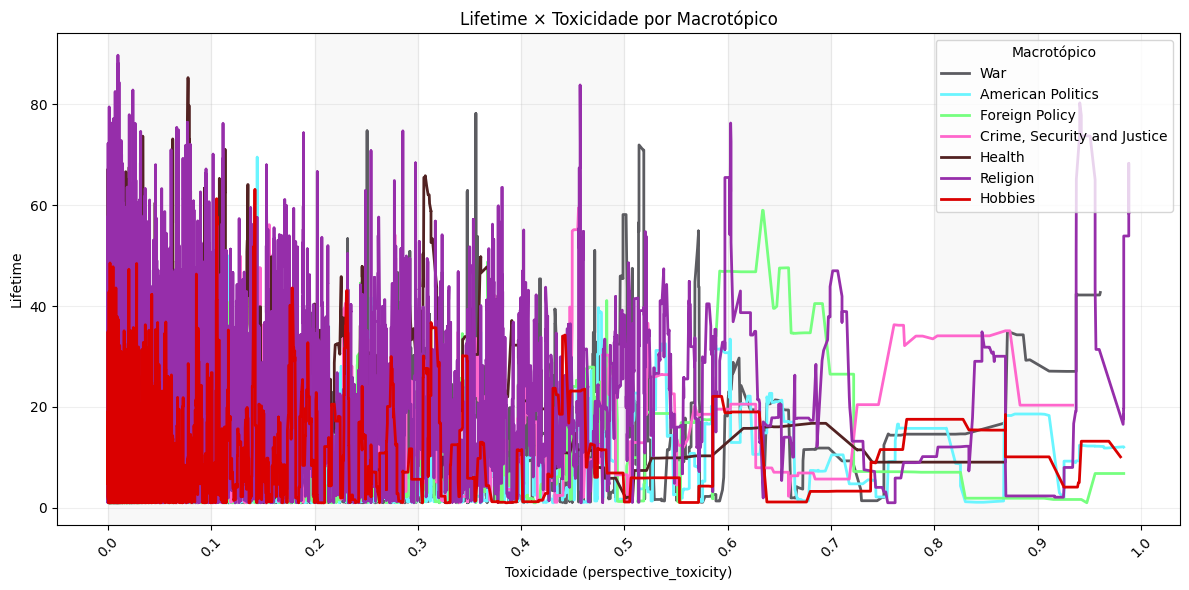

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df2 = df.copy()
df2 = df2.sort_values("perspective_toxicity")

# Criar o gráfico
plt.figure(figsize=(12, 6))

# ---------------------------
#  FAIXAS DE TOXICIDADE
# ---------------------------
bins = np.arange(0, 1.1, 0.1)
for i in range(len(bins) - 1):
    if i % 2 == 0:  # alterna faixas
        plt.axvspan(
            bins[i], bins[i+1],
            color="lightgray",
            alpha=0.15
        )

# ---------------------------
#  PLOTAGEM DAS LINHAS
# ---------------------------
for topic in interest:
    temp = df2[df2["macrotopic_pred"] == topic]

    if len(temp) == 0:
        continue

    temp = temp.sort_values("perspective_toxicity")

    # Suavização (opcional)
    window = 20
    smooth_y = temp["lifetime"].rolling(window, center=True).mean()

    plt.plot(
        temp["perspective_toxicity"],
        smooth_y,
        label=topic,
        color=macro_colors.get(topic, "black"),
        linewidth=2
    )

# ---------------------------
#  CONFIGURAÇÕES FINAIS
# ---------------------------
plt.xlabel("Toxicidade (perspective_toxicity)")
plt.ylabel("Lifetime")
plt.title("Lifetime × Toxicidade por Macrotópico")
plt.xticks(bins, rotation=45)
plt.grid(alpha=0.2)
plt.legend(title="Macrotópico")
plt.tight_layout()
plt.show()


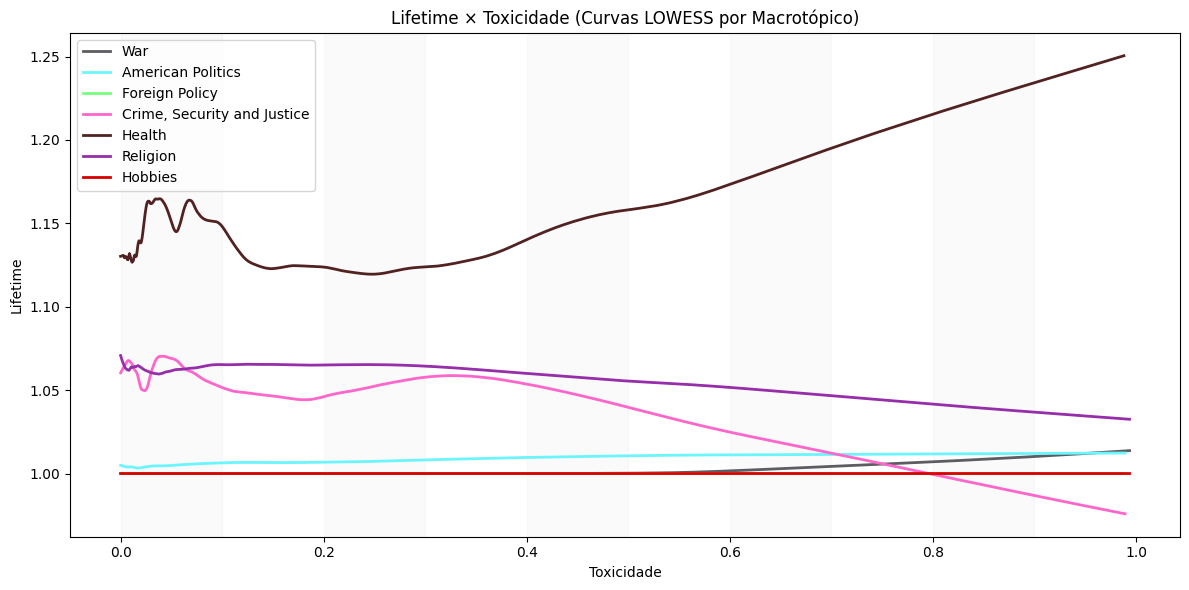

In [10]:
import statsmodels.api as sm

plt.figure(figsize=(12,6))

for topic in interest:
    temp = df2[df2["macrotopic_pred"] == topic]
    if len(temp) < 10:
        continue

    x = temp["perspective_toxicity"]
    y = temp["lifetime"]

    # LOWESS smoothing
    lowess = sm.nonparametric.lowess(y, x, frac=0.25)

    plt.plot(
        lowess[:,0],
        lowess[:,1],
        color=macro_colors[topic],
        label=topic,
        linewidth=2
    )

# Background shading
bins = np.arange(0,1.1,0.1)
for i in range(len(bins)-1):
    if i % 2 == 0:
        plt.axvspan(bins[i], bins[i+1], color="lightgray", alpha=0.1)

plt.xlabel("Toxicidade")
plt.ylabel("Lifetime")
plt.title("Lifetime × Toxicidade (Curvas LOWESS por Macrotópico)")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_595316/3441342569.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_f.groupby(["macrotopic_pred", "toxicity_bin"])["lifetime"]


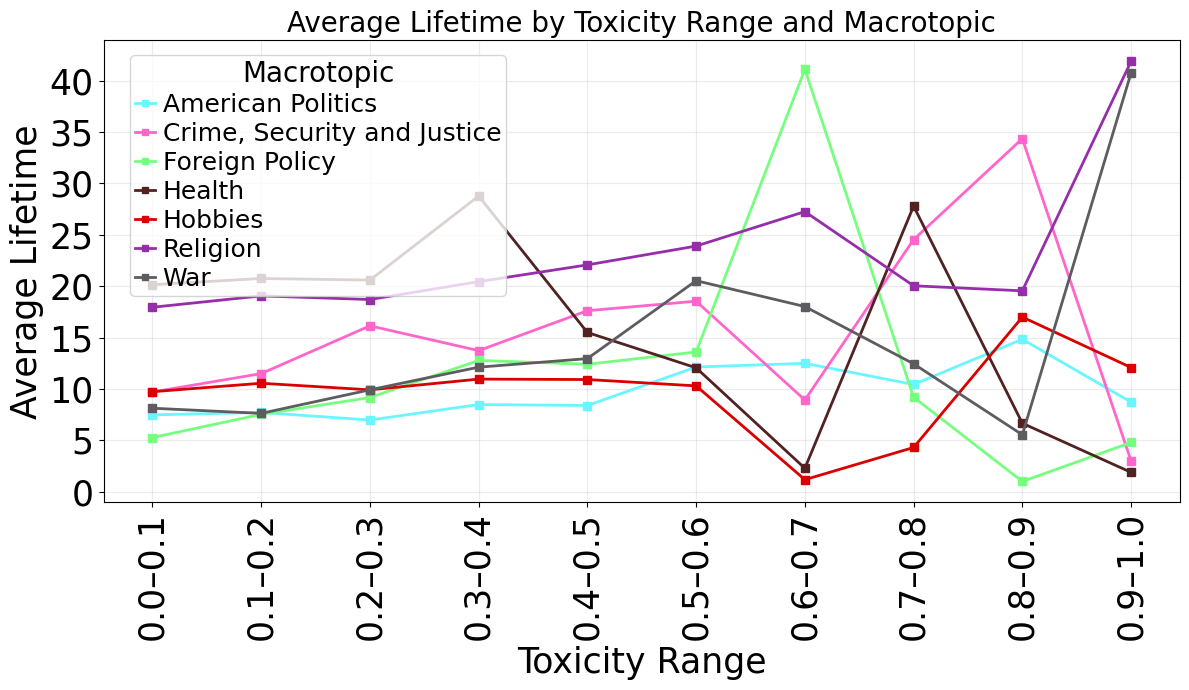

In [ ]:
df_f = df.copy()

bins = np.arange(0, 1.1, 0.1)
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]

df_f["toxicity_bin"] = pd.cut(
    df_f["perspective_toxicity"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calcular a MÉDIA do lifetime por faixa e tópico
grouped = (
    df_f.groupby(["macrotopic_pred", "toxicity_bin"])["lifetime"]
    .mean()
    .reset_index(name="avg_lifetime")
)

# Pivot para formato tabela
pivot = grouped.pivot(
    index="toxicity_bin",
    columns="macrotopic_pred",
    values="avg_lifetime"
)

# Plot
plt.figure(figsize=(12,7))

for topic in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[topic],
        marker="o",
        linewidth=2,
        color=macro_colors.get(topic, "black"),
        label=topic
    )

plt.xlabel("Toxicity Range", fontsize=25)
plt.ylabel("Average Lifetime", fontsize=25)
plt.title("Average Lifetime by Toxicity Range and Macrotopic", fontsize=20)
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=25)
plt.legend(
    title="Macrotopic",
    fontsize=18,
    title_fontsize=20,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),

    handlelength=0.8,      # marcador menor
    handletextpad=0.3,     # espaço entre marcador e texto
    markerscale=0.7,       # escala do marcador
    labelspacing=0.2,      # espaço entre linhas
    borderaxespad=0.2,     # afasta menos do gráfico
    borderpad=0.2,         # reduz espaço interno do bloco
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("lifetime_por_faixa_toxicidade_macrotopico.png")
plt.show()


/tmp/ipykernel_595316/865072269.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_f.groupby(["macrotopic_pred", "toxicity_bin"])["quantidade_envios"]


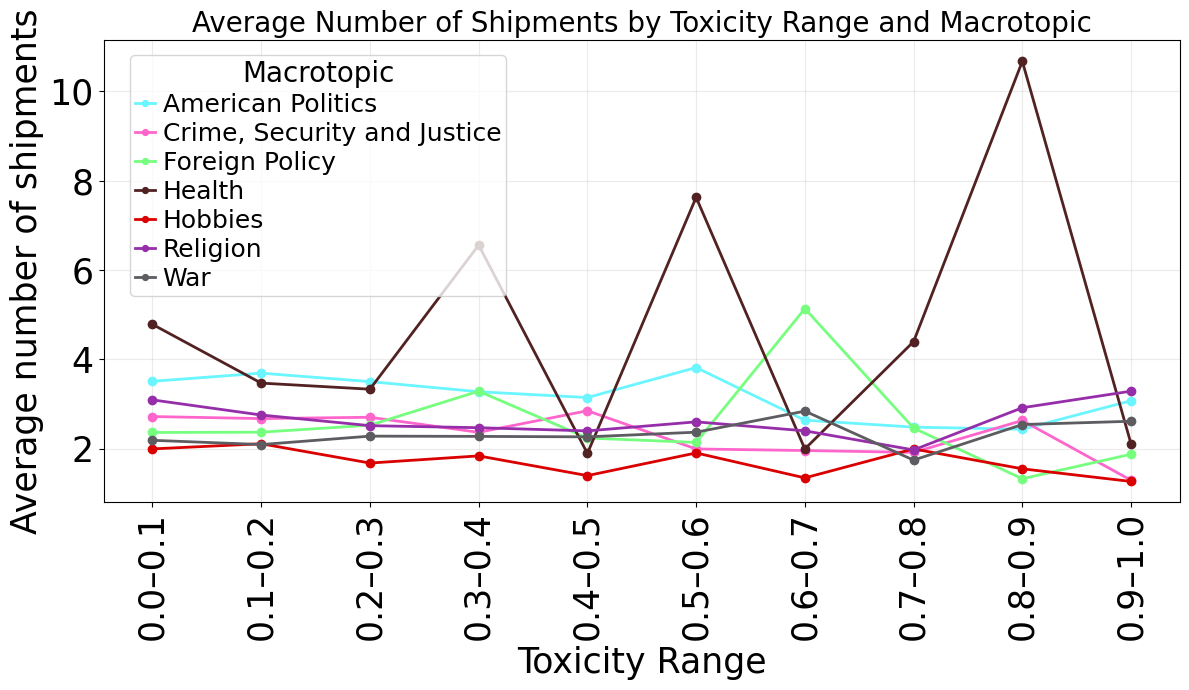

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_f = df.copy()

# Criar faixas de toxicidade (0.0 → 1.0)
bins = np.arange(0, 1.1, 0.1)
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]

df_f["toxicity_bin"] = pd.cut(
    df_f["perspective_toxicity"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calcular a MÉDIA de quantidade_envios por faixa e tópico
grouped = (
    df_f.groupby(["macrotopic_pred", "toxicity_bin"])["quantidade_envios"]
    .mean()
    .reset_index(name="avg_envios")
)

# Pivot para formato matriz
pivot = grouped.pivot(
    index="toxicity_bin",
    columns="macrotopic_pred",
    values="avg_envios"
)

# Plot
plt.figure(figsize=(12,7))

for topic in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[topic],
        marker="o",
        linewidth=2,
        color=macro_colors.get(topic, "black"),
        label=topic
    )

plt.xlabel("Toxicity Range", fontsize=25)
plt.ylabel("Average number of shipments", fontsize=25)
plt.title("Average Number of Shipments by Toxicity Range and Macrotopic", fontsize=20)
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=25)
plt.legend(
    title="Macrotopic",
    fontsize=18,
    title_fontsize=20,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),

    handlelength=0.8,      # marcador menor
    handletextpad=0.3,     # espaço entre marcador e texto
    markerscale=0.7,       # escala do marcador
    labelspacing=0.2,      # espaço entre linhas
    borderaxespad=0.2,     # afasta menos do gráfico
    borderpad=0.2,         # reduz espaço interno do bloco
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("quantidade_envios_por_faixa_toxicidade_macrotopico.png")
plt.show()

/tmp/ipykernel_595316/3162999687.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["macrotopic_pred", "Faixa_Toxicidade"])


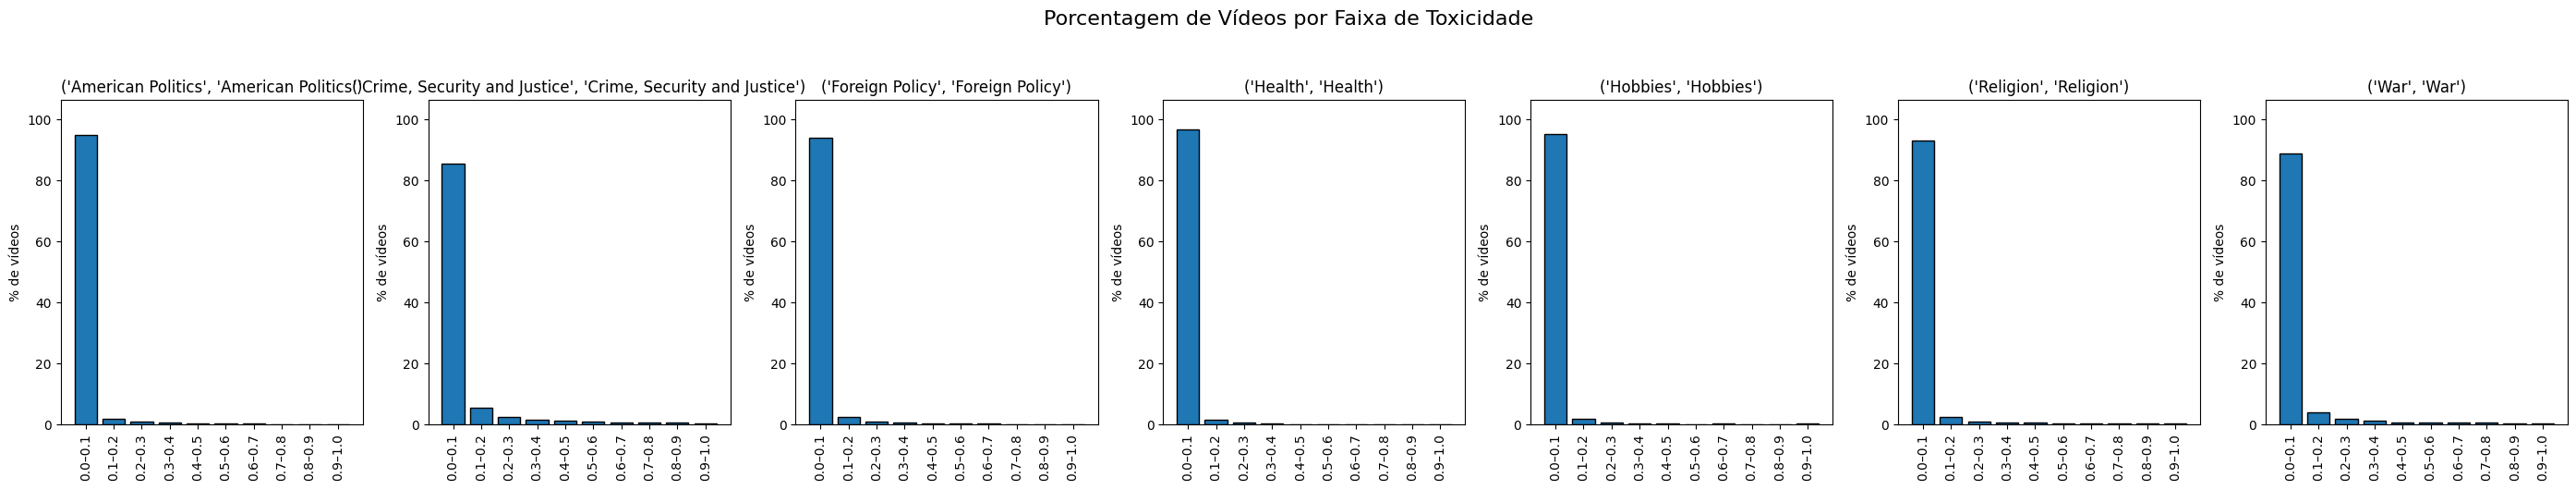


===== ('American Politics', 'American Politics') =====
0.0–0.1: 94.79%
0.1–0.2: 1.96%
0.2–0.3: 1.00%
0.3–0.4: 0.59%
0.4–0.5: 0.43%
0.5–0.6: 0.33%
0.6–0.7: 0.27%
0.7–0.8: 0.25%
0.8–0.9: 0.18%
0.9–1.0: 0.19%

===== ('Crime, Security and Justice', 'Crime, Security and Justice') =====
0.0–0.1: 85.47%
0.1–0.2: 5.67%
0.2–0.3: 2.51%
0.3–0.4: 1.53%
0.4–0.5: 1.31%
0.5–0.6: 0.95%
0.6–0.7: 0.71%
0.7–0.8: 0.71%
0.8–0.9: 0.67%
0.9–1.0: 0.47%

===== ('Foreign Policy', 'Foreign Policy') =====
0.0–0.1: 93.89%
0.1–0.2: 2.66%
0.2–0.3: 1.09%
0.3–0.4: 0.68%
0.4–0.5: 0.48%
0.5–0.6: 0.34%
0.6–0.7: 0.31%
0.7–0.8: 0.25%
0.8–0.9: 0.19%
0.9–1.0: 0.11%

===== ('Health', 'Health') =====
0.0–0.1: 96.63%
0.1–0.2: 1.54%
0.2–0.3: 0.61%
0.3–0.4: 0.37%
0.4–0.5: 0.24%
0.5–0.6: 0.22%
0.6–0.7: 0.11%
0.7–0.8: 0.10%
0.8–0.9: 0.11%
0.9–1.0: 0.05%

===== ('Hobbies', 'Hobbies') =====
0.0–0.1: 95.25%
0.1–0.2: 1.96%
0.2–0.3: 0.73%
0.3–0.4: 0.57%
0.4–0.5: 0.32%
0.5–0.6: 0.24%
0.6–0.7: 0.31%
0.7–0.8: 0.19%
0.8–0.9: 0.14%
0.9–1.0:

/tmp/ipykernel_595316/3162999687.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["macrotopic_pred", "Faixa_Toxicidade"])


In [31]:
import matplotlib.pyplot as plt

bins = np.arange(0, 1.1, 0.1) 
labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]

df["Faixa_Toxicidade"] = pd.cut(df["toxicity"], bins=bins, labels=labels, include_lowest=True)

tabela = (
    df.groupby(["macrotopic_pred", "Faixa_Toxicidade"])
      .size()
      .groupby(level=0)
      .apply(lambda x: 100 * x / x.sum())  # porcentagem
      .unstack(fill_value=0)
)


num_topics = len(tabela.index)
plt.figure(figsize=(4 * num_topics, 5))

for i, topic in enumerate(tabela.index, 1):
    valores = tabela.loc[topic].values
    
    plt.subplot(1, num_topics, i)
    plt.bar(labels, valores, edgecolor="black")
    plt.title(topic)
    plt.xticks(rotation=90)
    plt.ylabel("% de vídeos")
    plt.ylim(0, tabela.values.max() * 1.1)

plt.suptitle("Porcentagem de Vídeos por Faixa de Toxicidade", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

tabela = (
    df.groupby(["macrotopic_pred", "Faixa_Toxicidade"])
      .size()
      .groupby(level=0)
      .apply(lambda x: 100 * x / x.sum())
      .unstack(fill_value=0)
)

for topic in tabela.index:
    print(f"\n===== {topic} =====")
    for faixa in tabela.columns:
        porcentagem = tabela.loc[topic, faixa]
        print(f"{faixa}: {porcentagem:.2f}%")



In [32]:
df_exploded = df.explode('occurrences').reset_index(drop=True)
df_normalized = pd.json_normalize(df_exploded['occurrences'])
df_complete = pd.concat([
    df_exploded.drop(columns=['occurrences']), 
    df_normalized
], axis=1)
display(df_complete.head())

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,toxicity,severe_toxicity,obscene,...,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,quantidade_envios,Faixa_Toxicidade,id,folder,date
0,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,0.29500,0.001137,0.003694,...,0.049762,0.029415,Religion,0.000,1.0,1,0.2–0.3,60799.0,channel_1466271872,2024-01-06
1,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.017666,0.022509,Religion,0.005,2.0,5,0.0–0.1,449843.0,channel_1571505334,2024-10-27
2,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.017666,0.022509,Religion,0.005,2.0,5,0.0–0.1,205296.0,channel_1366456452,2024-10-28
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.017666,0.022509,Religion,0.005,2.0,5,0.0–0.1,123625.0,channel_2091154967,2024-10-27
4,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.017666,0.022509,Religion,0.005,2.0,5,0.0–0.1,462353.0,channel_1548295614,2024-10-27


In [33]:
len(df_complete)

851216

In [34]:
df_complete.columns

Index(['video_id', 'text', 'channel_title', 'published_at', 'view_count',
       'like_count', 'comment_count', 'toxicity', 'severe_toxicity', 'obscene',
       'threat', 'insult', 'identity_attack', 'perspective_insult',
       'perspective_severe_toxicity', 'perspective_obscene',
       'perspective_toxicity', 'perspective_identity_attack',
       'perspective_threat', 'macrotopic_pred', 'macrotopic_prob', 'lifetime',
       'quantidade_envios', 'Faixa_Toxicidade', 'id', 'folder', 'date'],
      dtype='object')

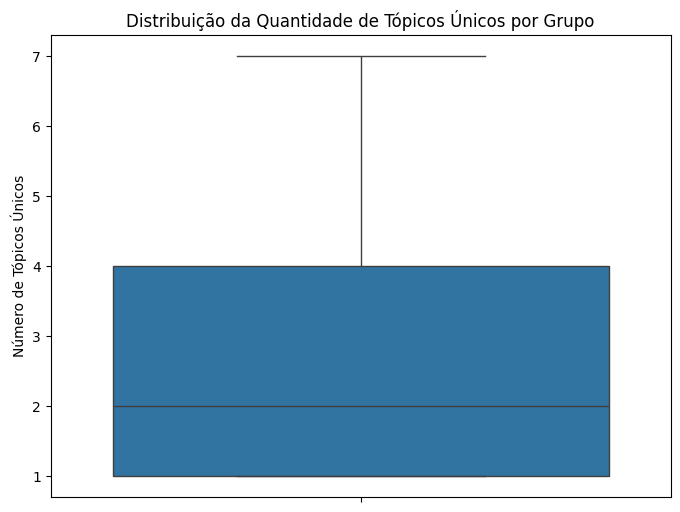

In [35]:
# Código Python recomendado

analise_topicos_por_grupo = (
    df_complete
    .groupby('folder')['macrotopic_pred']
    .nunique()
    .reset_index() # Opcional: converte a Series resultante de volta para um DataFrame
)

# Renomeia a coluna para maior clareza
analise_topicos_por_grupo.columns = ['Folder', 'Quantidade_Topicos_Unicos']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=analise_topicos_por_grupo['Quantidade_Topicos_Unicos'])

plt.title('Distribuição da Quantidade de Tópicos Únicos por Grupo')
plt.ylabel('Número de Tópicos Únicos')
plt.show()

/tmp/ipykernel_595316/2622745688.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Toxicidade_Faixa', 'macrotopic_pred'])
/tmp/ipykernel_595316/2622745688.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Toxicidade_Faixa', 'macrotopic_pred'])['folder']


Tabela de Análise de Concentração por Macrotópico:
   Toxicidade_Faixa              macrotopic_pred  Media_Videos_Por_Grupo
0        [0.0, 0.1)            American Politics               32.740049
1        [0.0, 0.1)  Crime, Security and Justice                8.021729
2        [0.0, 0.1)               Foreign Policy               20.310989
3        [0.0, 0.1)                       Health               17.723848
4        [0.0, 0.1)                      Hobbies                9.687263
5        [0.0, 0.1)                     Religion               46.445729
6        [0.0, 0.1)                          War               17.704193
7        [0.1, 0.2)            American Politics                9.810144
8        [0.1, 0.2)  Crime, Security and Justice                3.648893
9        [0.1, 0.2)               Foreign Policy                5.408066
10       [0.1, 0.2)                       Health                3.140748
11       [0.1, 0.2)                      Hobbies                2.866667


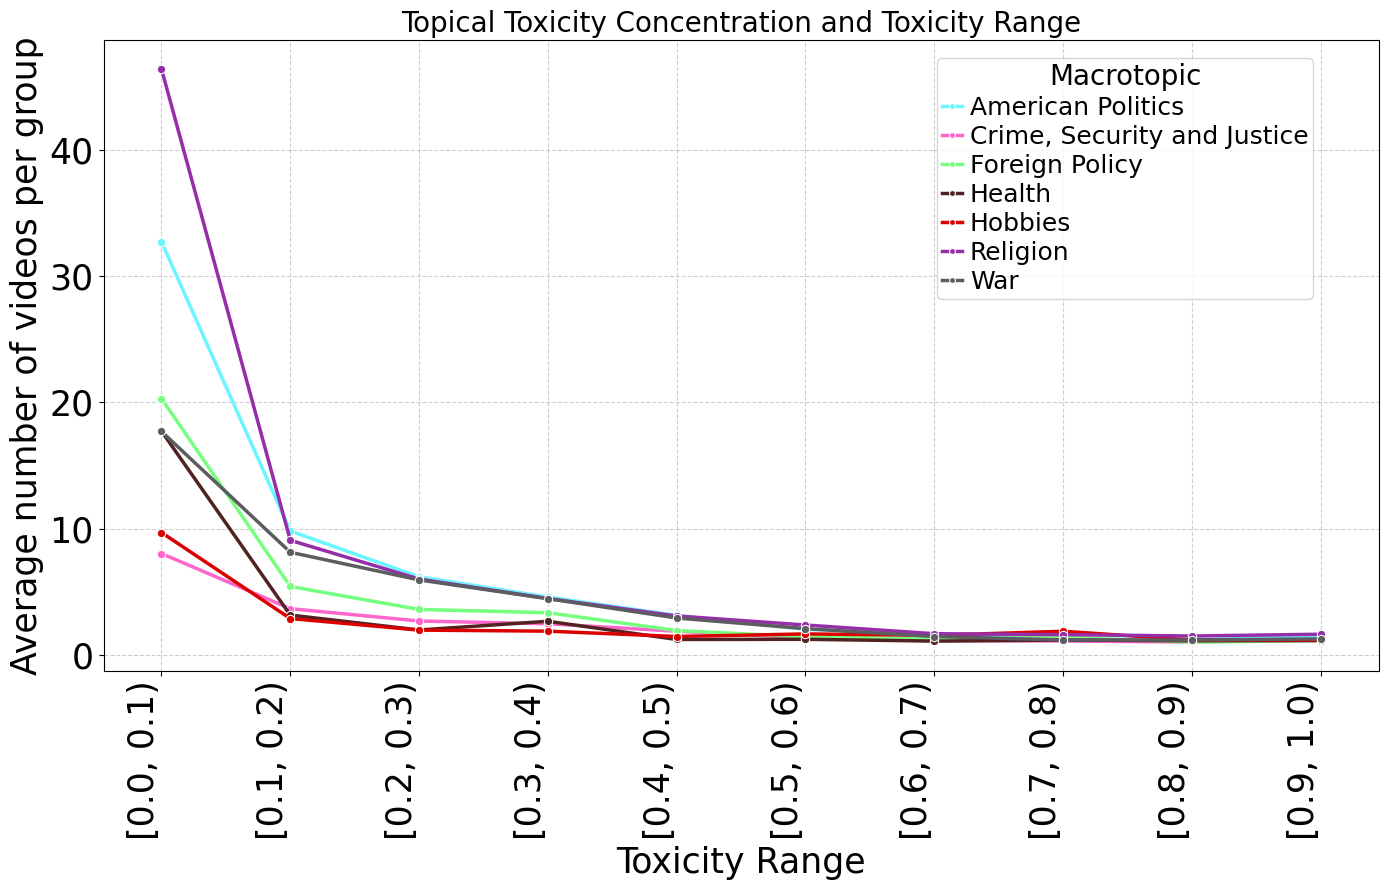

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cria as faixas de 0.1
bins = np.arange(0, 1.1, 0.1)
df_complete['Toxicidade_Faixa'] = pd.cut(
    df_complete['perspective_toxicity'], 
    bins=bins, 
    include_lowest=True, 
    right=False
)

# --- 2. Agregação e Cálculo da Métrica por Tópico ---

# 1. Contagem total de vídeos por (Faixa + Tópico)
quantidade_videos_por_macrotopico = (
    df_complete
    .groupby(['Toxicidade_Faixa', 'macrotopic_pred'])
    .size()
    .reset_index(name='Quantidade_Videos')
)

# 2. Contagem de grupos únicos por (Faixa + Tópico)
quantidade_grupos_distintos_macrotopico = (
    df_complete
    .groupby(['Toxicidade_Faixa', 'macrotopic_pred'])['folder']
    .nunique()
    .reset_index(name='Quantidade_Grupos_Distintos')
)

# 3. Combinar os resultados
analise_concentracao_macrotopico = pd.merge(
    quantidade_videos_por_macrotopico, 
    quantidade_grupos_distintos_macrotopico, 
    on=['Toxicidade_Faixa', 'macrotopic_pred']
)

# 4. Calcular a Média de Vídeos por Grupo Contribuinte (Concentração)
analise_concentracao_macrotopico['Media_Videos_Por_Grupo'] = np.divide(
    analise_concentracao_macrotopico['Quantidade_Videos'], 
    analise_concentracao_macrotopico['Quantidade_Grupos_Distintos'],
    # Configuração para evitar ZeroDivisionError, definindo o resultado como 0.0 quando o divisor é zero
    out=np.zeros_like(analise_concentracao_macrotopico['Quantidade_Videos'], dtype=float),
    where=analise_concentracao_macrotopico['Quantidade_Grupos_Distintos'] != 0
)

analise_concentracao_macrotopico['Toxicidade_Faixa_Str'] = (
    analise_concentracao_macrotopico['Toxicidade_Faixa']
    .astype(str)
)

# Exibe o resultado da tabela de análise
print("Tabela de Análise de Concentração por Macrotópico:")
print(analise_concentracao_macrotopico[['Toxicidade_Faixa', 'macrotopic_pred', 'Media_Videos_Por_Grupo']].head(15))

# --- 3. Visualização (Gráfico de Linhas) ---

plt.figure(figsize=(14, 9))

sns.lineplot(
    data=analise_concentracao_macrotopico,
    x='Toxicidade_Faixa_Str',
    y='Media_Videos_Por_Grupo',
    hue='macrotopic_pred',
    palette=macro_colors, 
    marker='o',
    linewidth=2.5
)

plt.title('Topical Toxicity Concentration and Toxicity Range', fontsize=20)
plt.xlabel('Toxicity Range', fontsize=25)
plt.ylabel('Average number of videos per group', fontsize=25)
plt.xticks(rotation=90, ha='right', fontsize=25)
plt.yticks(fontsize=25)
plt.legend(
    title="Macrotopic",
    fontsize=18,
    title_fontsize=20,
    loc="upper left",
    bbox_to_anchor=(0.65, 0.98),

    handlelength=0.8,      # marcador menor
    handletextpad=0.3,     # espaço entre marcador e texto
    markerscale=0.7,       # escala do marcador
    labelspacing=0.2,      # espaço entre linhas
    borderaxespad=0.2,     # afasta menos do gráfico
    borderpad=0.2,         # reduz espaço interno do bloco
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("concentracao_toxicidade_por_topico.png")
plt.show()


/tmp/ipykernel_595316/2350927494.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_distribuicao_canais = df_complete.groupby('toxicidade_faixa')['folder'].nunique().reset_index()


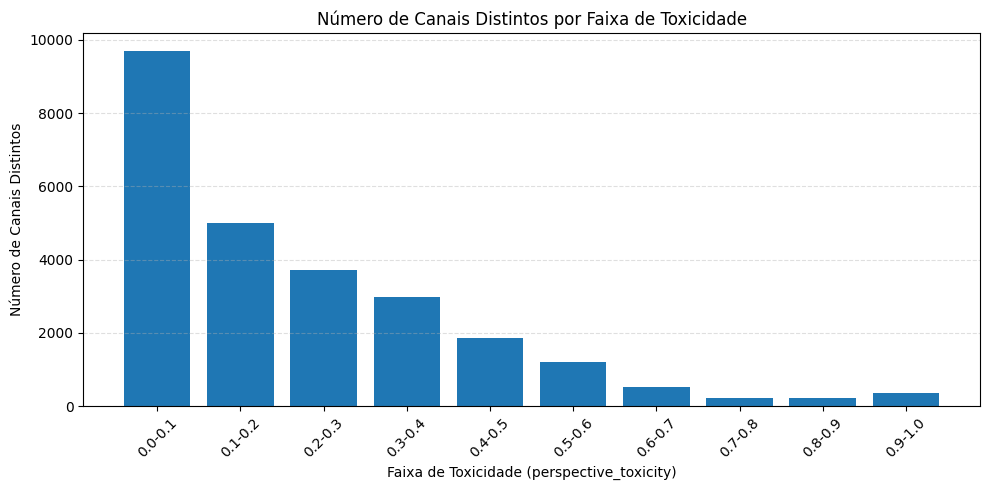

In [48]:
import pandas as pd
import numpy as np

# Definindo as bordas das faixas (de 0.0 a 1.0, com passo de 0.1)
bins = np.arange(0, 1.1, 0.1)

# Definindo os rótulos das faixas (ex: 0.0-0.1, 0.1-0.2, etc.)
labels = [f'{i:.1f}-{i+0.1:.1f}' for i in bins[:-1]]

# 1. Cria a coluna com as faixas de toxicidade
# O parâmetro 'right=False' garante que 0.1 seja incluído na próxima faixa (0.1-0.2)
df_complete['toxicidade_faixa'] = pd.cut(
    df_complete['perspective_toxicity'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# 2. Agrupar pela faixa e contar os canais ÚNICOS (nunique)
df_distribuicao_canais = df_complete.groupby('toxicidade_faixa')['folder'].nunique().reset_index()

# Renomeia a coluna resultante (o Eixo Y do seu gráfico)
df_distribuicao_canais = df_distribuicao_canais.rename(
    columns={'folder': 'num_canais_distintos'}
)

plt.figure(figsize=(10, 5))

plt.bar(
    df_distribuicao_canais["toxicidade_faixa"],
    df_distribuicao_canais["num_canais_distintos"]
)

plt.title("Número de Canais Distintos por Faixa de Toxicidade")
plt.xlabel("Faixa de Toxicidade (perspective_toxicity)")
plt.ylabel("Número de Canais Distintos")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

/tmp/ipykernel_595316/3048071664.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_complete.groupby(['macrotopic_pred', 'toxicidade_faixa'])['folder']


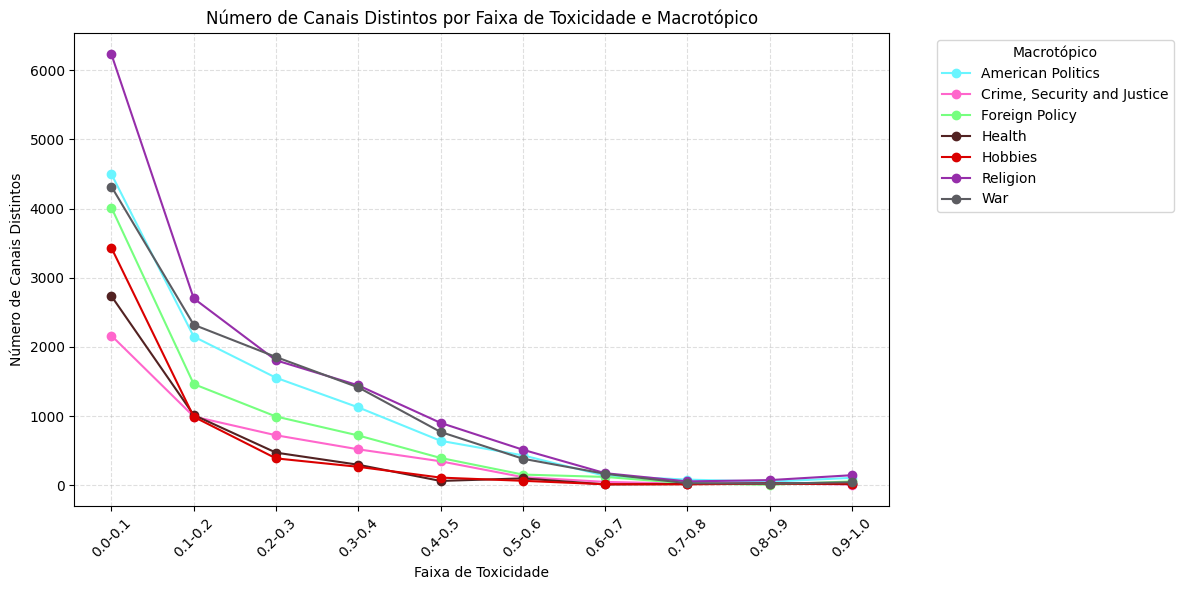

In [49]:
bins = np.arange(0, 1.1, 0.1)
labels = [f'{i:.1f}-{i+0.1:.1f}' for i in bins[:-1]]

df_complete['toxicidade_faixa'] = pd.cut(
    df_complete['perspective_toxicity'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# --- Criar tabela agrupada: canais únicos por faixa por macrotópico ---
df_distribuicao_canais_topic = (
    df_complete.groupby(['macrotopic_pred', 'toxicidade_faixa'])['folder']
    .nunique()
    .reset_index()
)

# --- Plot ---
plt.figure(figsize=(12, 6))

# Criar uma linha para cada macrotópico
for topic in df_distribuicao_canais_topic['macrotopic_pred'].unique():
    df_topic = df_distribuicao_canais_topic[df_distribuicao_canais_topic['macrotopic_pred'] == topic]

    plt.plot(
        df_topic['toxicidade_faixa'],
        df_topic['folder'],
        marker='o',
        linestyle='-',
        label=topic,
        color=macro_colors.get(topic, 'black')
    )

# Configurações
plt.title('Número de Canais Distintos por Faixa de Toxicidade e Macrotópico')
plt.xlabel('Faixa de Toxicidade')
plt.ylabel('Número de Canais Distintos')
plt.xticks(rotation=45)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.legend(title='Macrotópico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("distribuicao_canais_distintos_por_faixa_toxicidade_macrotopico.png")
plt.show()

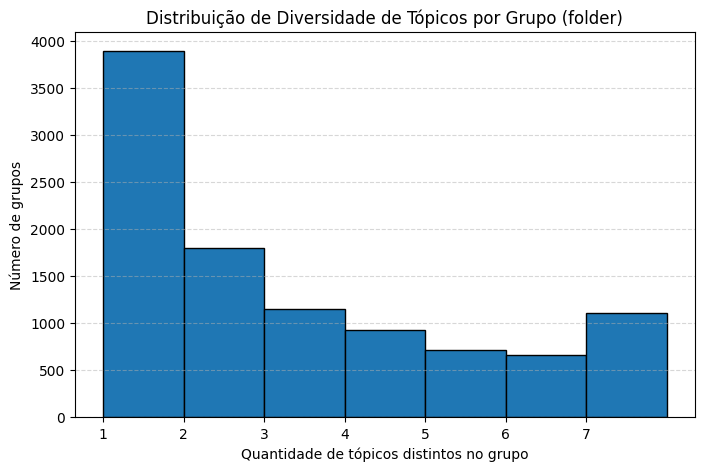

In [50]:
df_group = df_complete.groupby('folder')['macrotopic_pred'].nunique().reset_index(name='qtd_topicos_unicos')

plt.figure(figsize=(8,5))
plt.hist(df_group['qtd_topicos_unicos'], bins=range(1, df_group['qtd_topicos_unicos'].max()+2), edgecolor='black')
plt.xlabel("Quantidade de tópicos distintos no grupo")
plt.ylabel("Número de grupos")
plt.title("Distribuição de Diversidade de Tópicos por Grupo (folder)")
plt.xticks(range(1, df_group['qtd_topicos_unicos'].max()+1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



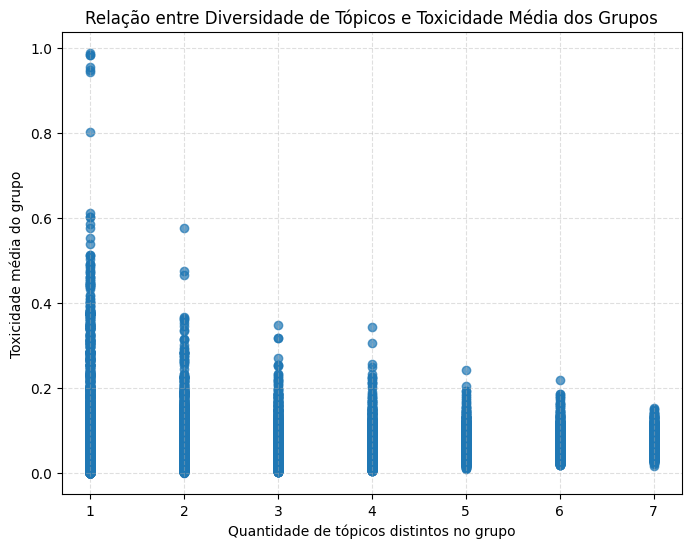

<Figure size 800x600 with 0 Axes>

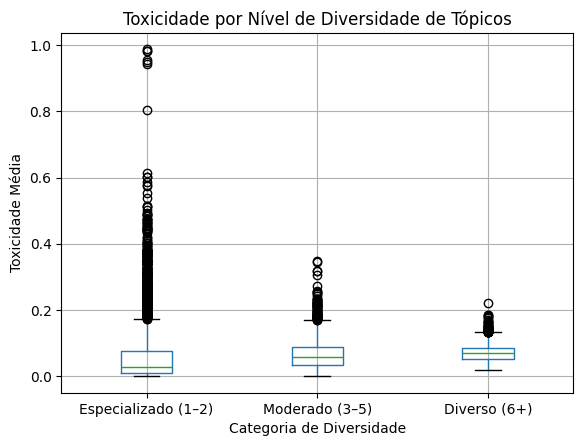

,qtd_topicos_unicos,tox_media
qtd_topicos_unicos,1.000000,0.056051
tox_media,0.056051,1.000000


In [51]:
# 1. Calcular toxicidade média por grupo
df_tox = df_complete.groupby('folder')['perspective_toxicity'].mean().reset_index(name='tox_media')

# 2. Juntar com o número de tópicos distintos por grupo
df_merge = df_group.merge(df_tox, on='folder')

# 3. Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(df_merge['qtd_topicos_unicos'], df_merge['tox_media'], alpha=0.7)
plt.xlabel("Quantidade de tópicos distintos no grupo")
plt.ylabel("Toxicidade média do grupo")
plt.title("Relação entre Diversidade de Tópicos e Toxicidade Média dos Grupos")
plt.grid(linestyle='--', alpha=0.4)
plt.show()

df_merge['categoria'] = pd.cut(
    df_merge['qtd_topicos_unicos'],
    bins=[0,2,5,20],
    labels=["Especializado (1–2)", "Moderado (3–5)", "Diverso (6+)"]
)

plt.figure(figsize=(8,6))
df_merge.boxplot(column='tox_media', by='categoria')
plt.title("Toxicidade por Nível de Diversidade de Tópicos")
plt.suptitle("")
plt.xlabel("Categoria de Diversidade")
plt.ylabel("Toxicidade Média")
plt.show()

df_merge[['qtd_topicos_unicos','tox_media']].corr()

In [52]:
import pandas as pd

# Toxicidade média por grupo
df_group = df_complete.groupby('folder').agg(
    tox_media=('perspective_toxicity', 'mean'),
    total_videos=('video_id', 'count')
).reset_index()

# Tópico predominante em cada grupo
topico_pred = (
    df_complete.groupby(['folder', 'macrotopic_pred'])
    .size()
    .reset_index(name='count')
)

topico_pred = topico_pred.loc[
    topico_pred.groupby('folder')['count'].idxmax()
]

df_group = df_group.merge(topico_pred[['folder', 'macrotopic_pred']], on='folder')


,macrotopic_pred,num_canais_distintos
5,Religion,6579
6,War,4903
0,American Politics,4876
2,Foreign Policy,4401
4,Hobbies,3676
3,Health,2915
1,"Crime, Security and Justice",2593


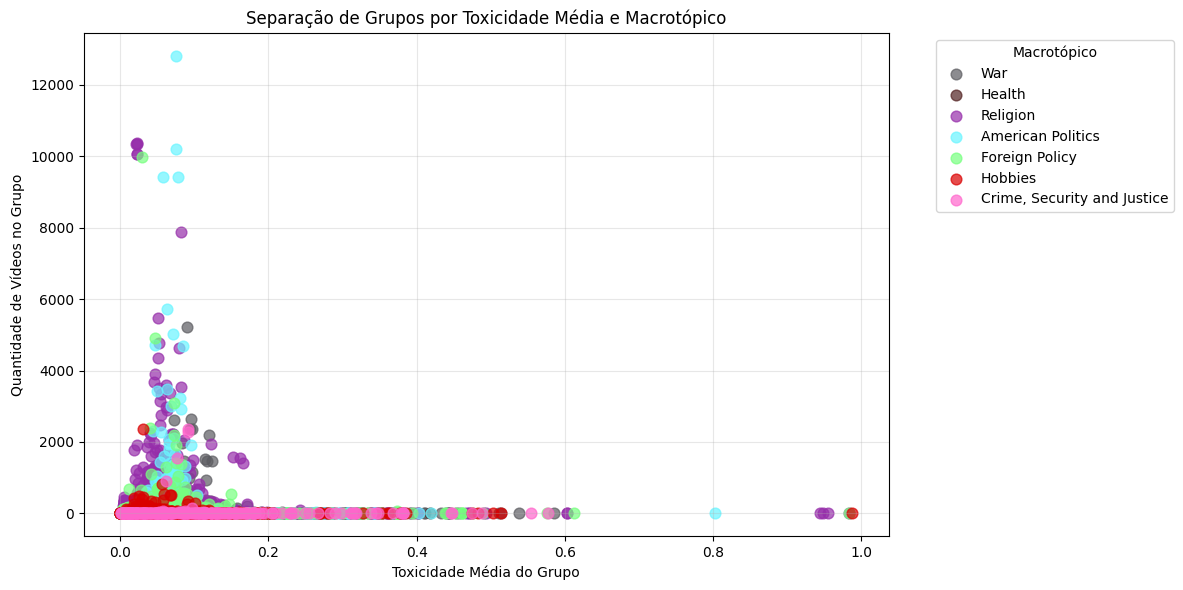

In [53]:
import pandas as pd

df_canais_unicos = df_complete.groupby('macrotopic_pred')['folder'].nunique().reset_index()

df_canais_unicos = df_canais_unicos.rename(
    columns={'folder': 'num_canais_distintos'}
)
df_canais_unicos = df_canais_unicos.sort_values(
    'num_canais_distintos',
    ascending=False
)

display(df_canais_unicos)

plt.figure(figsize=(12, 6))

for topic in df_group['macrotopic_pred'].unique():
    df_t = df_group[df_group['macrotopic_pred'] == topic]
    plt.scatter(
        df_t['tox_media'],
        df_t['total_videos'],
        label=topic,
        color=macro_colors.get(topic, 'black'),
        alpha=0.7,
        s=60
    )

plt.title("Separação de Grupos por Toxicidade Média e Macrotópico")
plt.xlabel("Toxicidade Média do Grupo")
plt.ylabel("Quantidade de Vídeos no Grupo")
plt.grid(alpha=0.3)
plt.legend(title="Macrotópico", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [54]:
df_video_channel_count = df_complete.groupby('video_id')['folder'].nunique().reset_index()

df_video_channel_count = df_video_channel_count.rename(
    columns={'folder': 'num_canais_por_video'}
)

df_map_topic = df_complete[['video_id', 'macrotopic_pred']].drop_duplicates()
df_videos_com_topic = df_video_channel_count.merge(
    df_map_topic, 
    on='video_id', 
    how='left'
)
df_media_canais_por_topico = df_videos_com_topic.groupby('macrotopic_pred')['num_canais_por_video'].mean().reset_index()

df_media_canais_por_topico = df_media_canais_por_topico.rename(
    columns={'num_canais_por_video': 'media_canais_por_video'}
)
df_media_canais_por_topico = df_media_canais_por_topico.sort_values(
    'media_canais_por_video', 
    ascending=False
)

df_styled = df_media_canais_por_topico.style.format({
    'media_canais_por_video': "{:.3f}"
})
display(df_styled)

,macrotopic_pred,media_canais_por_video
0,American Politics,3.160
3,Health,2.820
1,"Crime, Security and Justice",2.485
5,Religion,2.202
6,War,2.029
2,Foreign Policy,1.979
4,Hobbies,1.590


/tmp/ipykernel_595316/1104292129.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby(['macrotopic_pred', 'toxicity_bin']).size().reset_index(name='count')


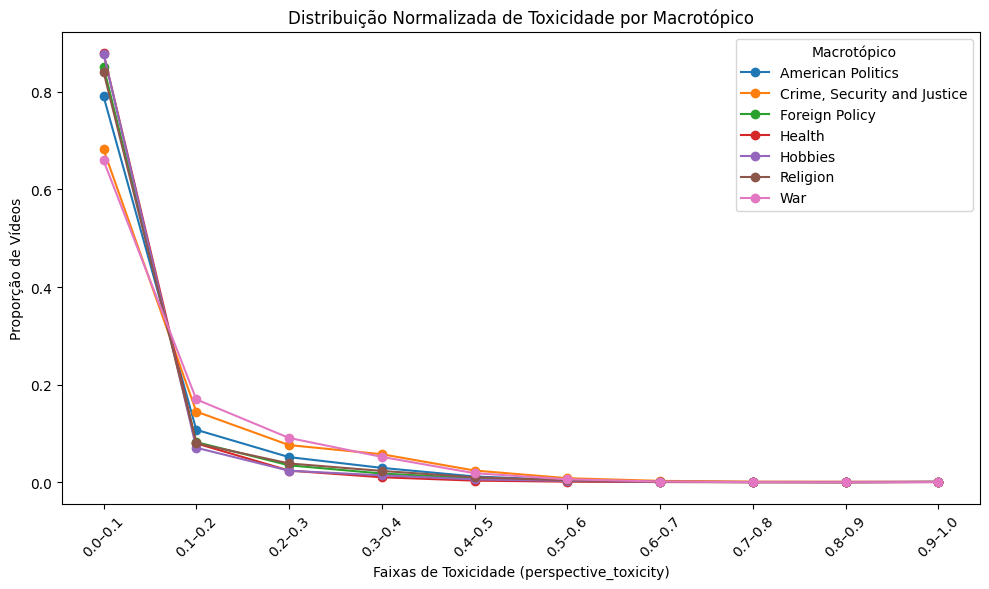

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Remover tópico Others
df_filtered = df[df['macrotopic_pred'] != "Others"].copy()

# Definir faixas de toxicidade
bins = np.arange(0, 1.1, 0.1)
labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]

df_filtered['toxicity_bin'] = pd.cut(
    df_filtered['perspective_toxicity'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Agrupar
grouped = df_filtered.groupby(['macrotopic_pred', 'toxicity_bin']).size().reset_index(name='count')

# Pivotar
pivot = grouped.pivot(index='toxicity_bin', columns='macrotopic_pred', values='count').fillna(0)

# Normalizar cada coluna (cada tópico)
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)

# Plotar
plt.figure(figsize=(10,6))

for topic in pivot_norm.columns:
    plt.plot(pivot_norm.index, pivot_norm[topic], marker='o', label=topic)

plt.xlabel("Faixas de Toxicidade (perspective_toxicity)")
plt.ylabel("Proporção de Vídeos")
plt.title("Distribuição Normalizada de Toxicidade por Macrotópico")
plt.xticks(rotation=45)
plt.legend(title="Macrotópico")
plt.tight_layout()
plt.show()


In [23]:
df_complete.columns

Index(['video_id', 'text', 'channel_title', 'published_at', 'view_count',
       'like_count', 'comment_count', 'toxicity', 'severe_toxicity', 'obscene',
       'threat', 'insult', 'identity_attack', 'perspective_insult',
       'perspective_severe_toxicity', 'perspective_obscene',
       'perspective_toxicity', 'perspective_identity_attack',
       'perspective_threat', 'macrotopic_pred', 'macrotopic_prob', 'lifetime',
       'quantidade_envios', 'id', 'folder', 'date'],
      dtype='object')

/tmp/ipykernel_1655518/841208975.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['macrotopic_pred', 'toxicity_bin'])['folder']


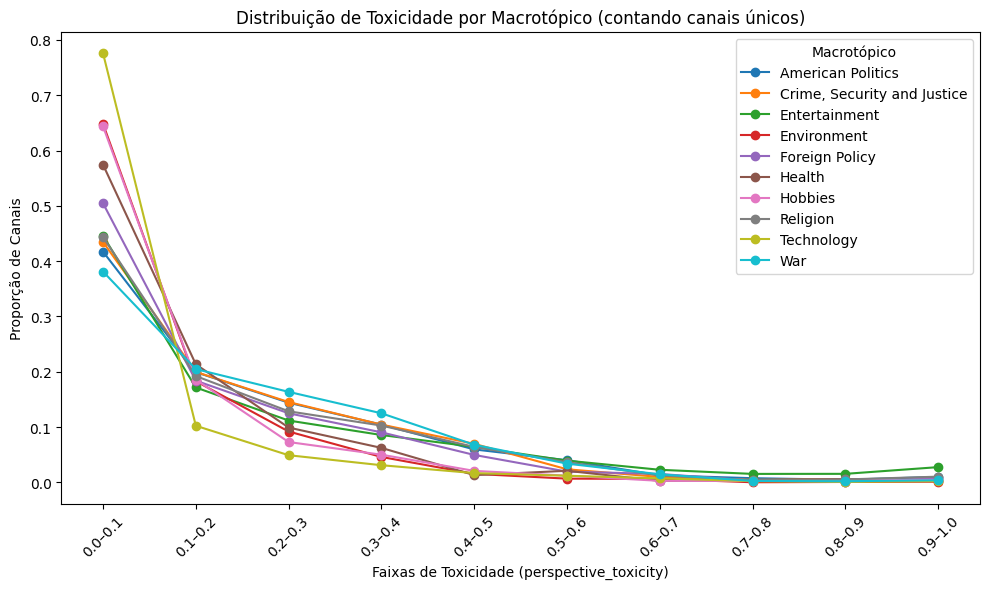

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_complete = df_complete[df_complete["macrotopic_pred"] != "Others"].copy()

# Definir faixas de toxicidade
bins = np.arange(0, 1.1, 0.1)
labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]

df_complete['toxicity_bin'] = pd.cut(
    df_complete['perspective_toxicity'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Agrupar por tópico + faixa e contar CANAIS ÚNICOS
grouped = (
    df_complete
    .groupby(['macrotopic_pred', 'toxicity_bin'])['folder']
    .nunique()
    .reset_index(name='unique_channels')
)

# Pivotar
pivot = grouped.pivot(index='toxicity_bin', columns='macrotopic_pred', values='unique_channels').fillna(0)

# Normalizar (opcional: para visualização melhor)
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)

# Plotar
plt.figure(figsize=(10,6))
for topic in pivot_norm.columns:
    plt.plot(pivot_norm.index, pivot_norm[topic], marker='o', label=topic)

plt.xlabel("Faixas de Toxicidade (perspective_toxicity)")
plt.ylabel("Proporção de Canais")
plt.title("Distribuição de Toxicidade por Macrotópico (contando canais únicos)")
plt.xticks(rotation=45)
plt.legend(title="Macrotópico")
plt.tight_layout()
plt.show()



===== RESULTADOS BRUTOS (canais únicos por faixa) =====
      macrotopic_pred toxicity_bin  unique_channels
0   American Politics      0.0–0.1             4497
1   American Politics      0.1–0.2             2149
2   American Politics      0.2–0.3             1554
3   American Politics      0.3–0.4             1126
4   American Politics      0.4–0.5              643
..                ...          ...              ...
95                War      0.5–0.6              384
96                War      0.6–0.7              166
97                War      0.7–0.8               30
98                War      0.8–0.9               24
99                War      0.9–1.0               44

[100 rows x 3 columns]

===== TABELA NORMALIZADA =====


/tmp/ipykernel_1655518/458920558.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby(["macrotopic_pred", "toxicity_bin"])["folder"]


macrotopic_pred,American Politics,"Crime, Security and Justice",Entertainment,Environment,Foreign Policy,Health,Hobbies,Religion,Technology,War
toxicity_bin,,,,,,,,,,
0.0–0.1,0.417123,0.434599,0.445982,0.648197,0.504589,0.574370,0.643715,0.443369,0.775840,0.381192
0.1–0.2,0.199332,0.199719,0.171613,0.182959,0.183956,0.213445,0.185741,0.192283,0.102410,0.204857
0.2–0.3,0.144142,0.145268,0.111848,0.092002,0.124984,0.099160,0.072983,0.128568,0.049144,0.163709
0.3–0.4,0.104443,0.104481,0.085689,0.046001,0.090532,0.062395,0.050094,0.102798,0.031072,0.124945
0.4–0.5,0.059642,0.069721,0.064223,0.015421,0.049667,0.013235,0.020826,0.064213,0.016804,0.068079
0.5–0.6,0.040163,0.023709,0.039355,0.006796,0.019490,0.021008,0.012195,0.036591,0.012048,0.033907
0.6–0.7,0.012708,0.009845,0.022815,0.006273,0.015214,0.002731,0.002814,0.012458,0.007292,0.014658
0.7–0.8,0.007606,0.004621,0.015367,0.000261,0.003395,0.003992,0.002627,0.003987,0.002219,0.002649
0.8–0.9,0.004823,0.005827,0.015484,0.000784,0.001006,0.006092,0.004503,0.005339,0.000951,0.002119


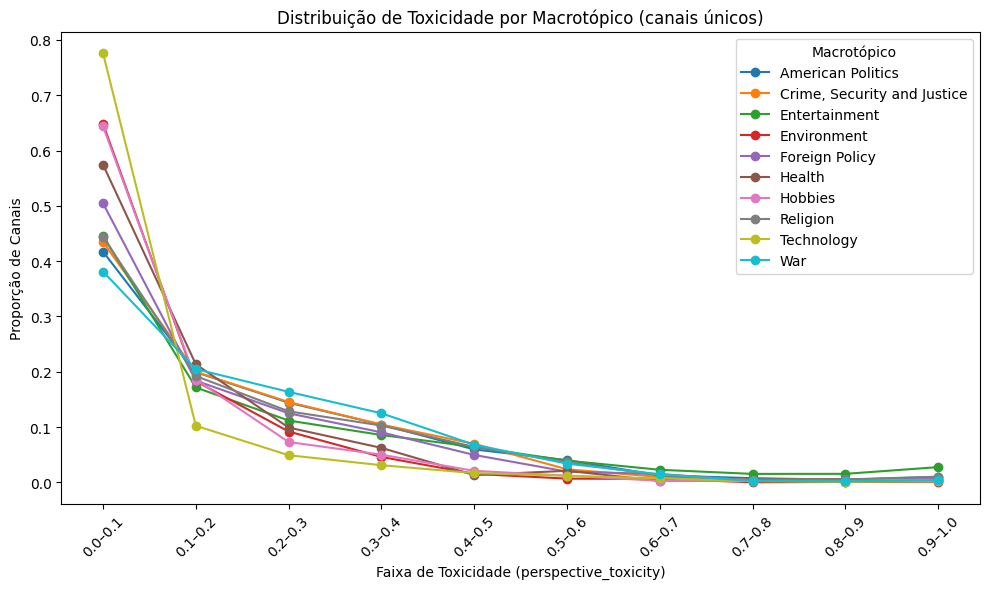

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Remover Others
df_c = df_complete[df_complete["macrotopic_pred"] != "Others"].copy()

# Criar faixas de toxicidade
bins = np.arange(0, 1.1, 0.1)
labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]

df_c["toxicity_bin"] = pd.cut(
    df_c["perspective_toxicity"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Agrupar: contar canais únicos por faixa e tópico
grouped = (
    df_c.groupby(["macrotopic_pred", "toxicity_bin"])["folder"]
    .nunique()
    .reset_index(name="unique_channels")
)

print("\n===== RESULTADOS BRUTOS (canais únicos por faixa) =====")
print(grouped)

# Pivotar para visualização
pivot = grouped.pivot(index="toxicity_bin", columns="macrotopic_pred", values="unique_channels").fillna(0)

# Normalizar (cada tópico vira proporção soma=1)
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)

print("\n===== TABELA NORMALIZADA =====")
display(pivot_norm)

# Plot do gráfico normalizado
plt.figure(figsize=(10,6))
for topic in pivot_norm.columns:
    plt.plot(pivot_norm.index, pivot_norm[topic], marker='o', label=topic)

plt.xlabel("Faixa de Toxicidade (perspective_toxicity)")
plt.ylabel("Proporção de Canais")
plt.title("Distribuição de Toxicidade por Macrotópico (canais únicos)")
plt.xticks(rotation=45)
plt.legend(title="Macrotópico")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1655518/2755438991.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_comparacao_politica = df_analise.groupby(


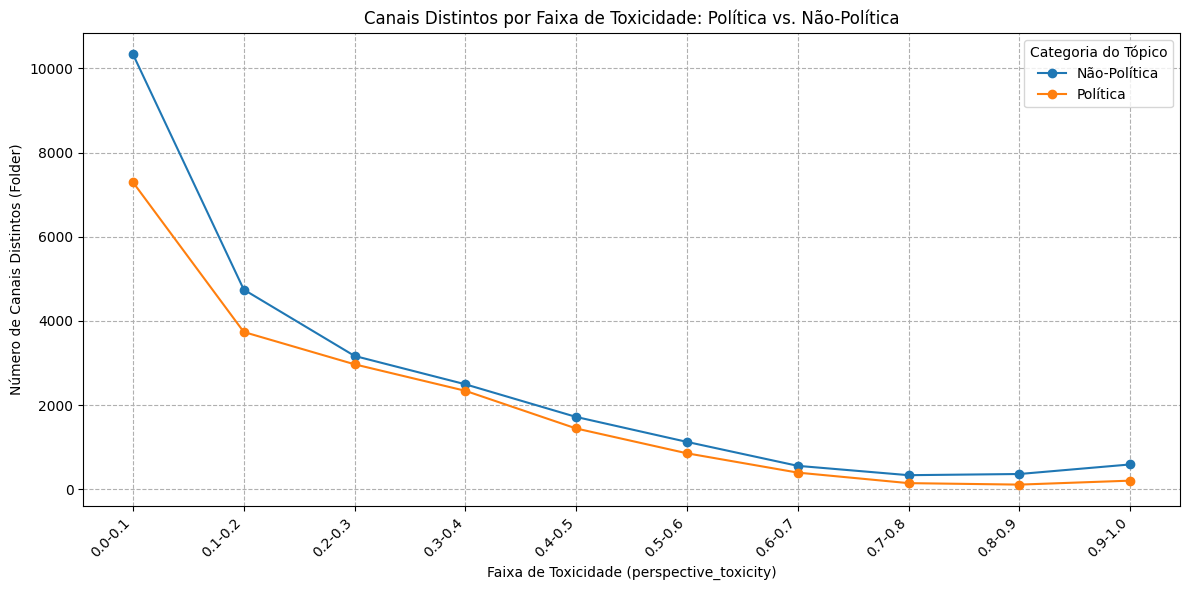

--- Dados Agregados (Política vs Não-Política) ---
   toxicidade_faixa     categoria  num_canais_distintos
0           0.0-0.1  Não-Política                 10334
1           0.0-0.1      Política                  7293
2           0.1-0.2  Não-Política                  4742
3           0.1-0.2      Política                  3735
4           0.2-0.3  Não-Política                  3166
5           0.2-0.3      Política                  2967
6           0.3-0.4  Não-Política                  2492
7           0.3-0.4      Política                  2337
8           0.4-0.5  Não-Política                  1716
9           0.4-0.5      Política                  1442
10          0.5-0.6  Não-Política                  1123
11          0.5-0.6      Política                   852
12          0.6-0.7  Não-Política                   554
13          0.6-0.7      Política                   393
14          0.7-0.8  Não-Política                   332
15          0.7-0.8      Política                   1

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definição dos tópicos políticos
political_topics = [
    "American Politics",
    "Foreign Policy",
    "War",
    "Crime, Security and Justice"
]

# 2. Cria a coluna de categoria (Política ou Não-Política)
df_analise['categoria'] = df_analise['macrotopic_pred'].apply(
    lambda x: 'Política' if x in political_topics else 'Não-Política'
)

# 3. Agrupamento Final: Faixa de Toxicidade E Categoria
# Contamos o número de canais ÚNICOS em cada Faixa, para cada Categoria.
df_comparacao_politica = df_analise.groupby(
    ['toxicidade_faixa', 'categoria']
)['folder'].nunique().reset_index()

df_comparacao_politica = df_comparacao_politica.rename(
    columns={'folder': 'num_canais_distintos'}
)

# 4. Plotagem do Gráfico de Linha
plt.figure(figsize=(12, 6))

# Itera sobre as duas categorias para plotar as duas linhas
for categoria in df_comparacao_politica['categoria'].unique():
    subset = df_comparacao_politica[df_comparacao_politica['categoria'] == categoria]
    plt.plot(
        subset['toxicidade_faixa'],
        subset['num_canais_distintos'],
        marker='o',
        label=categoria
    )

# Configuração do Gráfico
plt.title('Canais Distintos por Faixa de Toxicidade: Política vs. Não-Política')
plt.xlabel('Faixa de Toxicidade (perspective_toxicity)')
plt.ylabel('Número de Canais Distintos (Folder)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoria do Tópico')
plt.grid(axis='both', linestyle='--')
plt.tight_layout()
plt.show()

print("--- Dados Agregados (Política vs Não-Política) ---")
print(df_comparacao_politica)

In [17]:
df.columns

Index(['video_id', 'text', 'channel_title', 'published_at', 'view_count',
       'like_count', 'comment_count', 'occurrences', 'toxicity',
       'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack',
       'perspective_insult', 'perspective_severe_toxicity',
       'perspective_obscene', 'perspective_toxicity',
       'perspective_identity_attack', 'perspective_threat', 'macrotopic_pred',
       'macrotopic_prob', 'Toxicidade_Faixa', 'Toxicidade_Faixa_Str',
       'like_rate', 'comment_rate'],
      dtype='object')

/tmp/ipykernel_595316/4210243215.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = df.groupby(["macrotopic_pred", "Faixa_Views"]).size().unstack(fill_value=0)


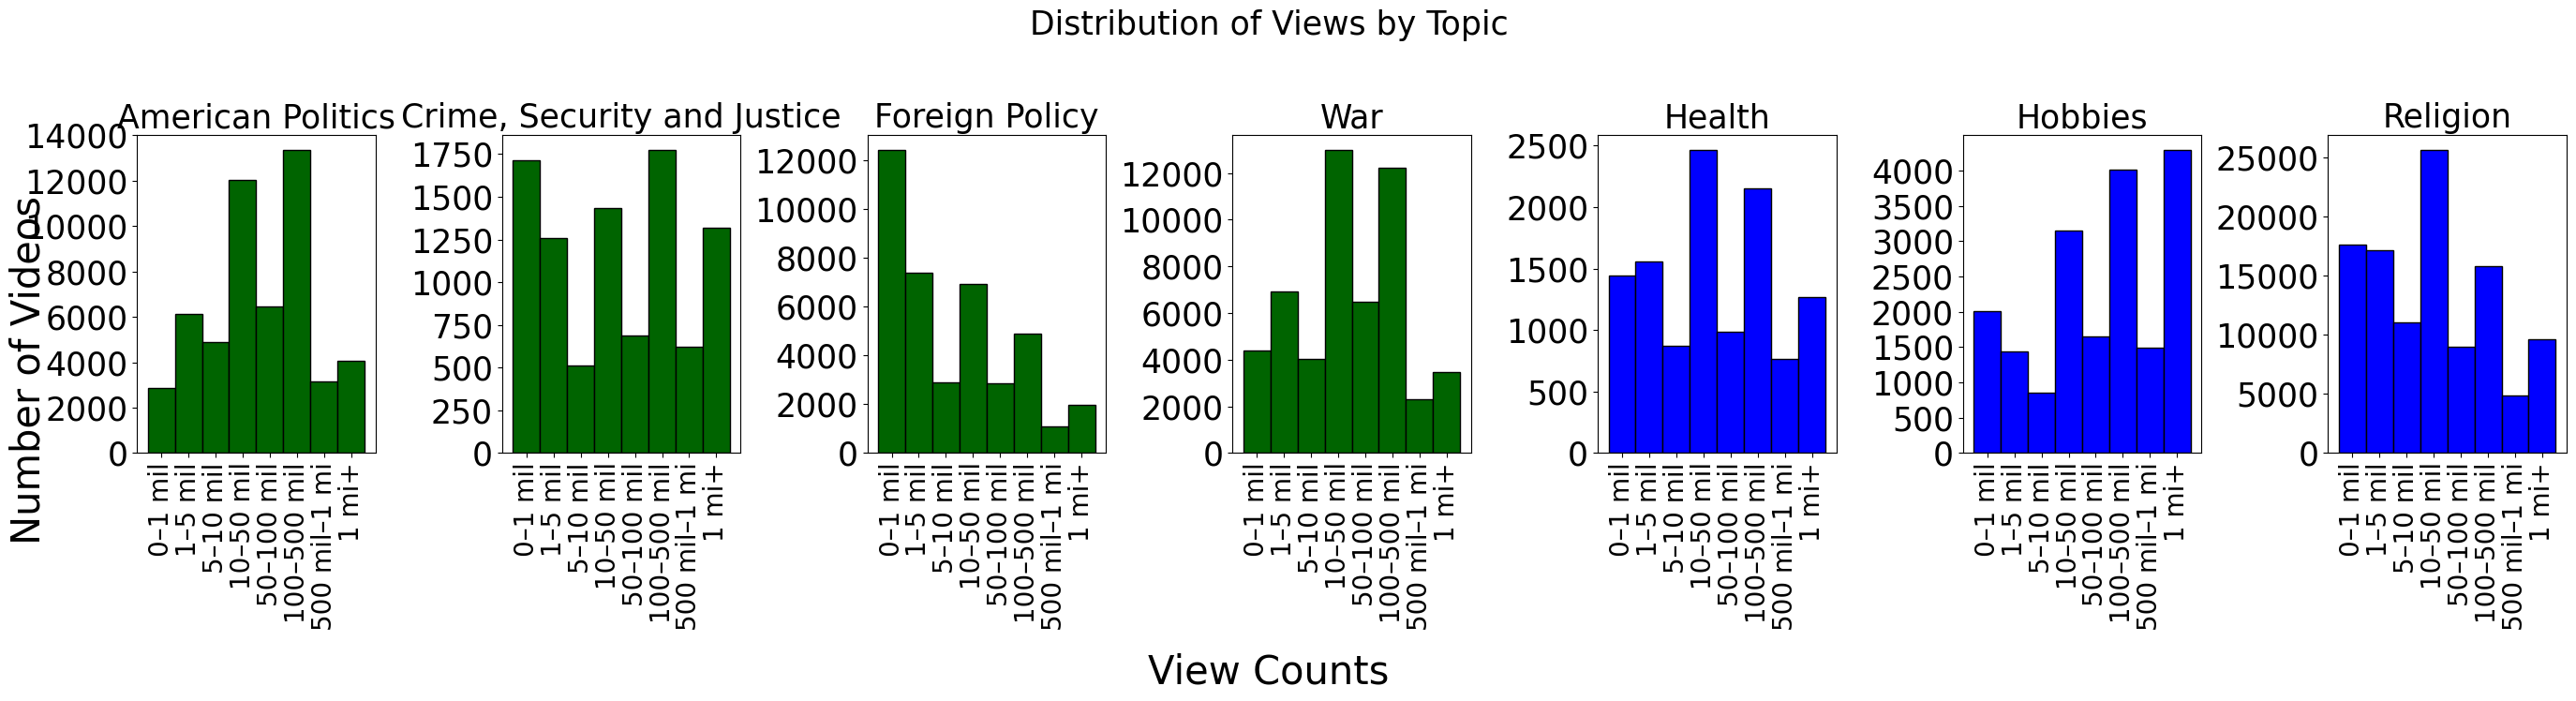

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# NOVAS FAIXAS DE VISUALIZAÇÃO
# ============================
bins = [
    0, 1_000, 5_000, 10_000, 50_000,
    100_000, 500_000, 1_000_000, np.inf
]

labels = [
    "0–1 mil", "1–5 mil", "5–10 mil", "10–50 mil",
    "50–100 mil", "100–500 mil", "500 mil–1 mi", "1 mi+"
]

df["Faixa_Views"] = pd.cut(df["view_count"], bins=bins, labels=labels, right=False)

# ============================
# CONTAGEM POR TÓPICO E FAIXA
# ============================
tabela = df.groupby(["macrotopic_pred", "Faixa_Views"]).size().unstack(fill_value=0)

# ============================
# DEFINIR CORES POR TÓPICO
# ============================
topicos_verdes = {
    "American Politics",
    "Crime, Security and Justice",
    "Foreign Policy",
    "War"
}

def cor_do_topico(topic):
    return "darkgreen" if topic in topicos_verdes else "blue"

ordenados = sorted(tabela.index, key=lambda x: (x not in topicos_verdes, x))
tabela = tabela.loc[ordenados]

# ============================
# GRÁFICO — UM SUBPLOT POR TÓPICO
# ============================
num_topics = len(tabela.index)

fig = plt.figure(figsize=(4 * num_topics, 7))

for i, topic in enumerate(tabela.index, 1):
    valores = tabela.loc[topic].values

    plt.subplot(1, num_topics, i)
    plt.bar(labels, valores, width=1.0, edgecolor="black", color=cor_do_topico(topic))
    plt.xticks(rotation=90, fontsize = 20)
    plt.yticks(fontsize=25)
    plt.title(topic, fontsize=25)
    plt.tight_layout()

fig.supxlabel("View Counts", fontsize=30)
fig.supylabel("Number of Videos", fontsize=30)

plt.suptitle("Distribution of Views by Topic", y=1.05, fontsize=25)
plt.tight_layout()
plt.savefig("distribuicao_views_por_topico.png")
plt.show()


/tmp/ipykernel_2277046/63316441.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Toxicidade_Faixa", "Toxicidade_Faixa_Str", "macrotopic_pred"])["view_count"]


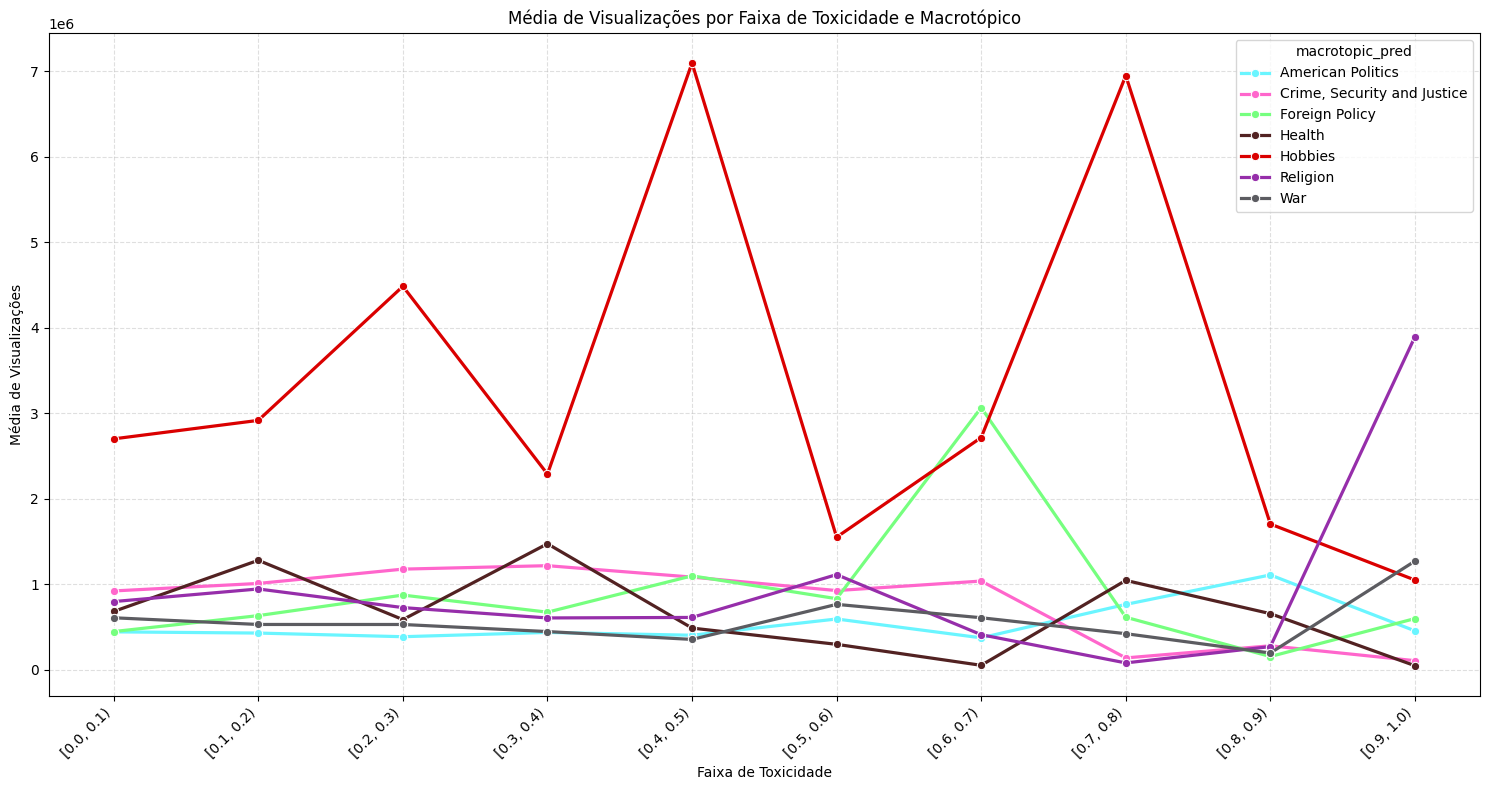

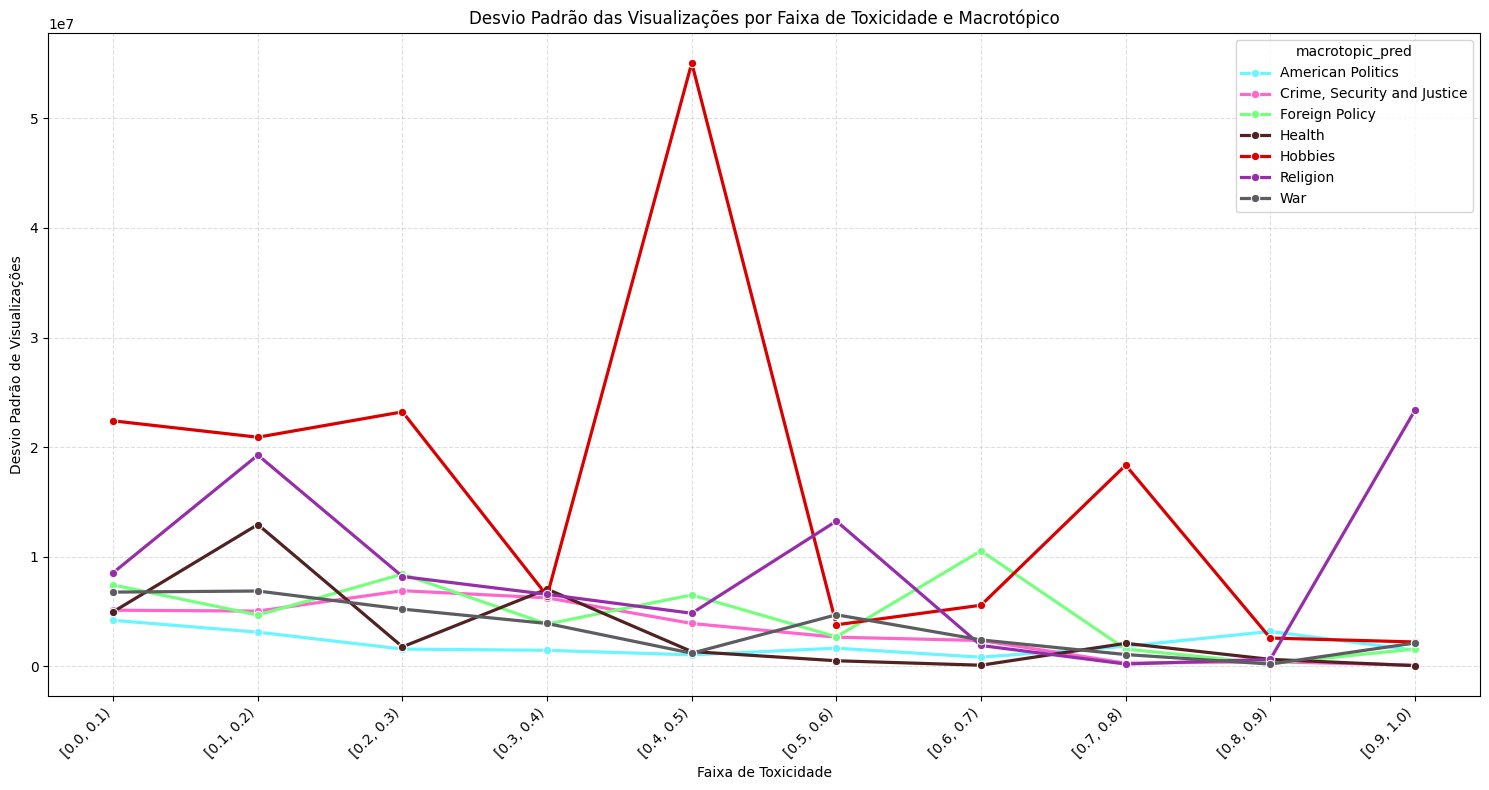

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1. Criar faixas de toxicidade
# -------------------------------
bins = np.arange(0, 1.1, 0.1)
df["Toxicidade_Faixa"] = pd.cut(
    df["perspective_toxicity"],
    bins=bins,
    include_lowest=True,
    right=False
)

df["Toxicidade_Faixa_Str"] = df["Toxicidade_Faixa"].astype(str)

# -------------------------------
# 2. Filtrar macrotópicos
# -------------------------------
df_filt = df[df["macrotopic_pred"].isin(interest)]

# -------------------------------
# 3. Calcular média e desvio padrão
# -------------------------------
stats = (
    df_filt
    .groupby(["Toxicidade_Faixa", "Toxicidade_Faixa_Str", "macrotopic_pred"])["view_count"]
    .agg(["mean", "std"])
    .reset_index()
)

# -------------------------------
# 4. GRÁFICO 1: Média
# -------------------------------
plt.figure(figsize=(15, 8))

sns.lineplot(
    data=stats,
    x="Toxicidade_Faixa_Str",
    y="mean",
    hue="macrotopic_pred",
    palette=macro_colors,
    marker="o",
    linewidth=2.3
)

plt.title("Média de Visualizações por Faixa de Toxicidade e Macrotópico")
plt.xlabel("Faixa de Toxicidade")
plt.ylabel("Média de Visualizações")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# -------------------------------
# 5. GRÁFICO 2: Desvio Padrão
# -------------------------------
plt.figure(figsize=(15, 8))

sns.lineplot(
    data=stats,
    x="Toxicidade_Faixa_Str",
    y="std",
    hue="macrotopic_pred",
    palette=macro_colors,
    marker="o",
    linewidth=2.3
)

plt.title("Desvio Padrão das Visualizações por Faixa de Toxicidade e Macrotópico")
plt.xlabel("Faixa de Toxicidade")
plt.ylabel("Desvio Padrão de Visualizações")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


/tmp/ipykernel_595316/2332303865.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["like_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_595316/2332303865.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Toxicidade_Faixa", "macrotopic_pred"])["like_rate"]


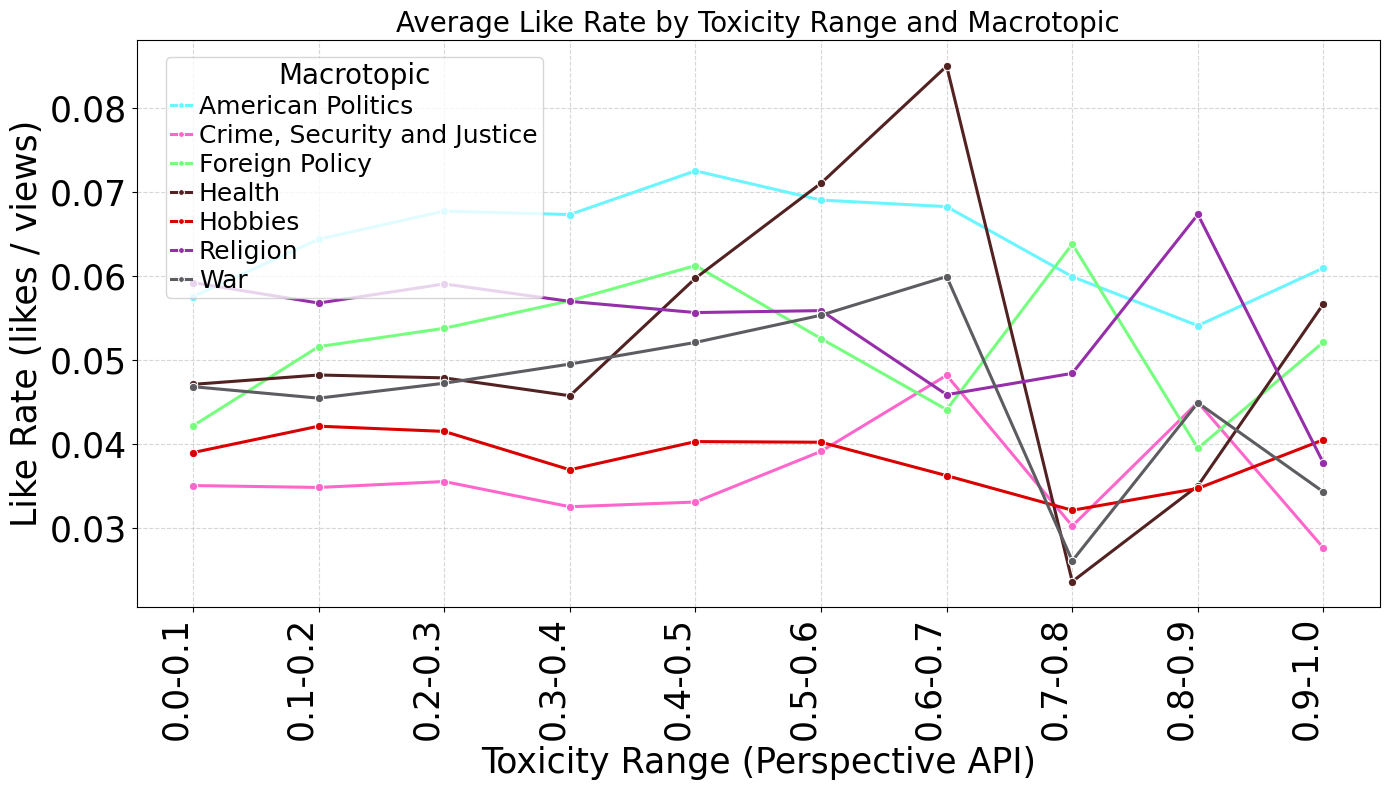

In [77]:
df["like_rate"] = df["like_count"] / df["view_count"]

# Evitar divisões por zero ou NaN
df["like_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["like_rate"])

# ------------------------------
# 3. Criar faixas de toxicidade
# ------------------------------
bins = np.arange(0, 1.1, 0.1)
labels = [f"{b:.1f}-{b+0.1:.1f}" for b in bins[:-1]]

df["Toxicidade_Faixa"] = pd.cut(
    df["perspective_toxicity"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# ------------------------------
# 4. Agrupar e calcular a média do Like Rate
# ------------------------------
df_like_rate = (
    df.groupby(["Toxicidade_Faixa", "macrotopic_pred"])["like_rate"]
      .mean()
      .reset_index()
)

# ------------------------------
# 5. Visualização
# ------------------------------
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_like_rate,
    x="Toxicidade_Faixa",
    y="like_rate",
    hue="macrotopic_pred",
    palette=macro_colors,
    marker="o",
    linewidth=2.2
)

plt.title("Average Like Rate by Toxicity Range and Macrotopic", fontsize=20)
plt.xlabel("Toxicity Range (Perspective API)", fontsize=25)
plt.ylabel("Like Rate (likes / views)", fontsize=25)
plt.xticks(rotation=90, ha='right', fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    title="Macrotopic",
    fontsize=18,
    title_fontsize=20,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),

    handlelength=0.8,      # marcador menor
    handletextpad=0.3,     # espaço entre marcador e texto
    markerscale=0.7,       # escala do marcador
    labelspacing=0.2,      # espaço entre linhas
    borderaxespad=0.2,     # afasta menos do gráfico
    borderpad=0.2,         # reduz espaço interno do bloco
)
plt.tight_layout()
plt.savefig("like_rate_por_faixa_toxicidade_macrotopico.png")
plt.show()

/tmp/ipykernel_595316/2081851352.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["comment_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_595316/2081851352.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Toxicidade_Faixa", "macrotopic_pred"])["comment_rate"]


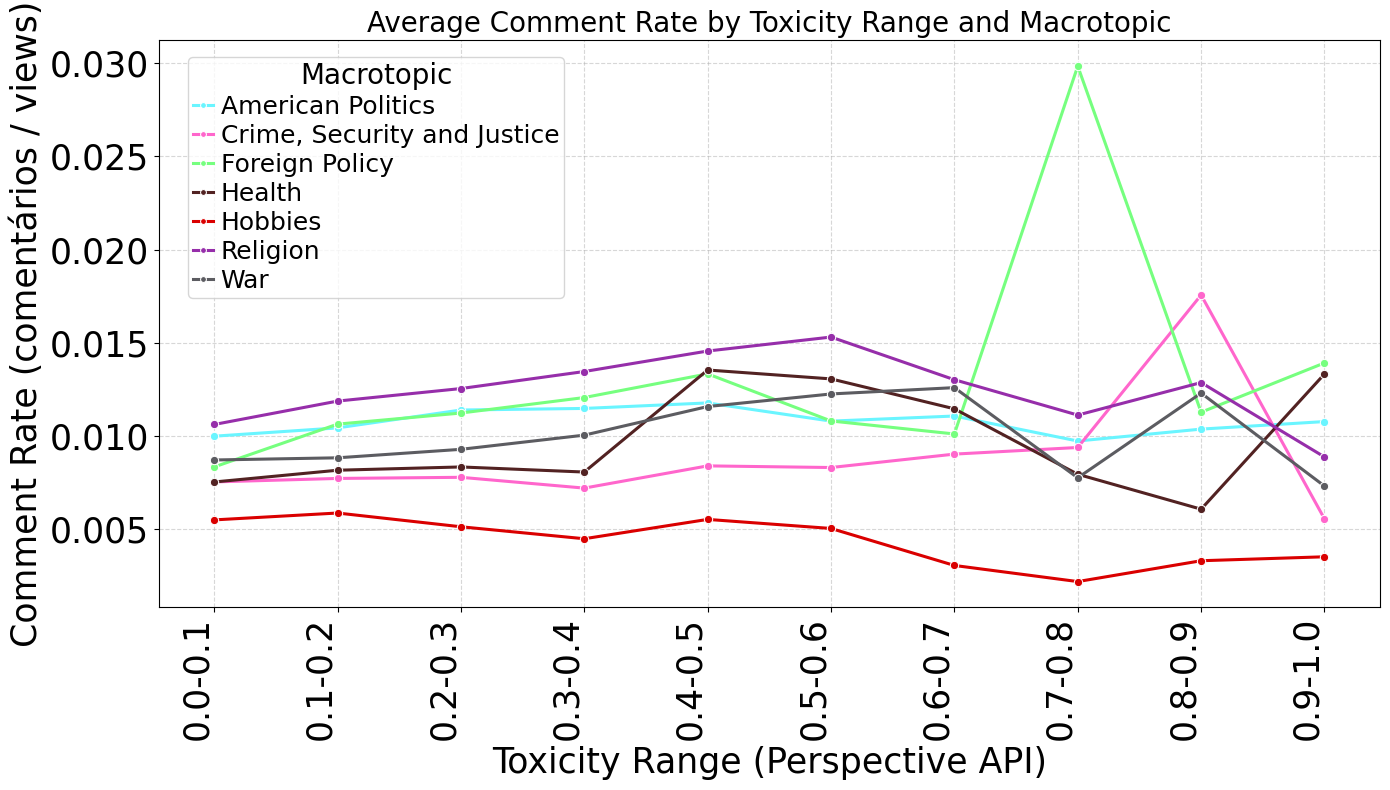

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Calcular Comment Rate
# ------------------------------
df["comment_rate"] = df["comment_count"] / df["view_count"]

# Evitar divisões por zero ou NaN
df["comment_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=["comment_rate"])

# ------------------------------
# 2. Criar faixas de toxicidade
# ------------------------------
bins = np.arange(0, 1.1, 0.1)
labels = [f"{b:.1f}-{b+0.1:.1f}" for b in bins[:-1]]

df["Toxicidade_Faixa"] = pd.cut(
    df["perspective_toxicity"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# ------------------------------
# 3. Agrupar e calcular a média do Comment Rate
# ------------------------------
df_comment_rate = (
    df.groupby(["Toxicidade_Faixa", "macrotopic_pred"])["comment_rate"]
      .mean()
      .reset_index()
)

# ------------------------------
# 4. Visualização
# ------------------------------
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_comment_rate,
    x="Toxicidade_Faixa",
    y="comment_rate",
    hue="macrotopic_pred",
    palette=macro_colors,
    marker="o",
    linewidth=2.2
)

plt.title("Average Comment Rate by Toxicity Range and Macrotopic", fontsize=20)
plt.xlabel("Toxicity Range (Perspective API)", fontsize=25)
plt.ylabel("Comment Rate (comentários / views)", fontsize=25)
plt.xticks(rotation=90, ha='right', fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    title="Macrotopic",
    fontsize=18,
    title_fontsize=20,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),

    handlelength=0.8,      # marcador menor
    handletextpad=0.3,     # espaço entre marcador e texto
    markerscale=0.7,       # escala do marcador
    labelspacing=0.2,      # espaço entre linhas
    borderaxespad=0.2,     # afasta menos do gráfico
    borderpad=0.2,         # reduz espaço interno do bloco
)
plt.tight_layout()
plt.savefig("comment_rate_por_faixa_toxicidade_macrotopico.png")
plt.show()


In [8]:
df["like_rate"] = df["like_count"] / df["view_count"]

# comment_rate = comments / views
df["comment_rate"] = df["comment_count"] / df["view_count"]

# Tratar divisões por zero e inf
df["like_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["comment_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)

# ------------------------------
# 3. Agrupar por macrotópico e calcular médias
# ------------------------------
df_metricas = (
    df.groupby("macrotopic_pred")
      .agg(
           media_views=("view_count", "mean"),
           media_likes=("like_count", "mean"),
           media_comentarios=("comment_count", "mean"),
           media_like_view=("like_rate", "mean"),
           media_comentario_view=("comment_rate", "mean")
      )
      .reset_index()
)

# ------------------------------
# 4. Ordenar por qualquer métrica (opcional)
# ------------------------------
df_metricas = df_metricas.sort_values("media_views", ascending=False)

# ------------------------------
# 5. Mostrar resultado
# ------------------------------
display(df_metricas)

/tmp/ipykernel_2277046/4256292810.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["like_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_2277046/4256292810.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

,macrotopic_pred,media_views,media_likes,media_comentarios,media_like_view,media_comentario_view
4,Hobbies,2.783791e+06,56201.804624,1735.423351,0.039194,0.005507
1,"Crime, Security and Justice",9.481095e+05,27321.994182,2408.058926,0.034887,0.007619
5,Religion,7.995722e+05,17469.539125,1053.941521,0.058869,0.010929
3,Health,7.235226e+05,18556.169890,1155.618548,0.047262,0.007657
6,War,5.585227e+05,15551.371551,1258.138240,0.046899,0.008949
2,Foreign Policy,4.864694e+05,11651.918450,898.299155,0.043781,0.008770
0,American Politics,4.402233e+05,13710.279610,1620.173466,0.059337,0.010191
